## EV Route Finding System

## Initial Neighbor Finding Code

In [3]:
import pandas as pd
import networkx as nx
from geopy.distance import geodesic
import random
from sklearn.cluster import DBSCAN
import numpy as np
from collections import deque,defaultdict
import math
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
# Keep only stations with valid coordinates and charger counts
df = pd.read_csv("./ev-charging-station.csv")
df_clean = df.dropna(subset=['Latitude', 'Longitude', 'EV Level2 EVSE Num', 'EV Connector Types']).reset_index(drop=True)
df_clean['EV Level2 EVSE Num'] = df_clean['EV Level2 EVSE Num'].astype(int)

# Parse connector types into sets
df_clean['connector_set'] = df_clean['EV Connector Types'].apply(lambda x: set(map(str.strip, x.split(','))) if isinstance(x, str) else set())

# Clustering
coords = df_clean[['Latitude', 'Longitude']].to_numpy()
kms_per_radian = 6371.0088
epsilon = 20.0 / kms_per_radian  # ~20 km radius
db = DBSCAN(eps=epsilon, min_samples=1, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
df_clean['cluster'] = db.labels_

# Group by cluster and aggregate
df_clustered = df_clean.groupby('cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'EV Level2 EVSE Num': 'sum',
    'connector_set': lambda sets: set().union(*sets)
}).reset_index(drop=True)

G = nx.Graph()
for idx, row in df_clustered.iterrows():
    G.add_node(
        idx,
        pos=(row['Latitude'], row['Longitude']),
        chargers=row['EV Level2 EVSE Num'],
        connector_types=row['connector_set']
    )

def distance(i, j):
    return geodesic(G.nodes[i]['pos'], G.nodes[j]['pos']).km

def angle_between(lat1, lon1, lat2, lon2):
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    angle = math.degrees(math.atan2(dlon, dlat)) % 360
    return angle

# number of nearest neighbors per node
k = 5

print("Graph node count:", len(G.nodes))
print("Connecting each node to its", k, "nearest neighbors...")

for i in G.nodes:
    distances = []
    lat1, lon1 = G.nodes[i]['pos']

    for j in G.nodes:
        if i == j:
            continue
        lat2, lon2 = G.nodes[j]['pos']
        dist = distance(i, j)
        distances.append((dist, j))

    distances.sort()
    nearest_neighbors = [j for _, j in distances[:k]]

    for j in nearest_neighbors:
        dist = distance(i, j)
        weight = dist / (1 + G.nodes[j]['chargers'])
        G.add_edge(i, j, weight=weight)

    print(f"Node {i} → Neighbors: {nearest_neighbors}")

# Save
with open("graph_data.gpickle", "wb") as f:
    pickle.dump(G, f)

C:\Users\Sarvesh Ram Kumar\AppData\Local\Temp\ipykernel_8252\3988376000.py:2: DtypeWarning: Columns (5,6,26,38,48,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./ev-charging-station.csv")


Graph node count: 2076
Connecting each node to its 5 nearest neighbors...
Node 0 → Neighbors: [743, 101, 131, 1464, 773]
Node 1 → Neighbors: [1723, 2048, 1544, 1995, 845]
Node 2 → Neighbors: [1601, 725, 578, 718, 228]
Node 3 → Neighbors: [470, 1591, 255, 817, 162]
Node 4 → Neighbors: [372, 556, 249, 300, 1042]
Node 5 → Neighbors: [1174, 908, 1254, 359, 191]
Node 6 → Neighbors: [929, 473, 315, 1807, 740]
Node 7 → Neighbors: [1874, 1718, 1034, 1101, 651]
Node 8 → Neighbors: [557, 348, 1877, 1833, 1430]
Node 9 → Neighbors: [1889, 1165, 1360, 595, 625]
Node 10 → Neighbors: [591, 1158, 528, 1751, 700]
Node 11 → Neighbors: [609, 1105, 342, 1663, 1373]
Node 12 → Neighbors: [1484, 1261, 1647, 1059, 1498]
Node 13 → Neighbors: [1576, 1626, 545, 468, 1548]
Node 14 → Neighbors: [798, 1590, 1231, 1800, 1129]
Node 15 → Neighbors: [1102, 523, 282, 1891, 1868]
Node 16 → Neighbors: [1778, 467, 1210, 1224, 1117]
Node 17 → Neighbors: [1554, 1773, 1959, 1479, 881]
Node 18 → Neighbors: [1871, 582, 1084, 19

In [4]:
# Load
with open("graph_data.gpickle", "rb") as f:
    G = pickle.load(f)

## The Environment the Car is going to work upon and Double Q-Learning Algorithm

In [5]:
class EVRouteEnv:
    def __init__(self, graph, start, goal, preferred_connector_type=None):
        self.graph = graph
        self.start = start
        self.goal = goal
        self.preferred_connector_type = preferred_connector_type
        self.reset()

    def reset(self):
        self.state = self.start
        self.visited = {self.start}
        self.steps = 0
        self.distance = 0
        self.visit_counts = defaultdict(int)
        return self.state

    def step(self, action):
        if action not in self.graph[self.state]:
            return self.state, -10, 10, False  # penalty + high "cost"

        self.steps += 1
        prev_pos = self.graph.nodes[self.state]['pos']
        next_pos = self.graph.nodes[action]['pos']
        dist = geodesic(prev_pos, next_pos).km
        self.distance += dist

        # ---- base reward and cost ----
        reward = -dist            # smaller distance = higher reward
        cost = dist               # cost = travel distance

        # connector-aware bonus / penalty
        node_data = self.graph.nodes[action]
        if node_data.get('chargers', 0) > 0:
            connectors = node_data.get('connector_types', [])
            if self.preferred_connector_type in connectors:
                reward += 10
            else:
                reward -= 3

        # progress toward goal
        prev_goal = geodesic(prev_pos, self.graph.nodes[self.goal]['pos']).km
        new_goal = geodesic(next_pos, self.graph.nodes[self.goal]['pos']).km
        reward += 0.5 * (prev_goal - new_goal)

        # delay + loop penalties
        reward -= min(0.01 * (1.05 ** self.steps), 900)
        if action in self.visited:
            visits = self.visit_counts.get(action, 1)
            reward -= 100 * visits
            cost += 5 * visits  # add to cost too
            self.visit_counts[action] = visits + 1
        else:
            self.visit_counts[action] = 1

        self.state = action
        self.visited.add(action)

        done = self.state == self.goal
        if done:
            reward += 10000

        return self.state, reward, cost, done

    def get_actions(self, state):
        return list(self.graph[state])


# ---------- DUAL-Q AGENT ----------
class DualQAgent:
    def __init__(self, graph, alpha=0.1, gamma=0.9, epsilon=0.2,
                 mu=0.05, target_cost=5.0, mu_lr=0.01):
        self.graph = graph
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.mu = mu                   # adaptive weight between reward and cost
        self.target_cost = target_cost # desired average travel cost per step
        self.mu_lr = mu_lr             # learning rate for μ
        self.QR = defaultdict(float)
        self.QC = defaultdict(float)

    def choose_action(self, state, actions):
        if random.random() < self.epsilon:
            return random.choice(actions)
        scores = []
        for a in actions:
            q_r = self.QR[(state, a)]
            q_c = self.QC[(state, a)]
            score = q_r - self.mu * q_c
            scores.append(score)
        return actions[int(np.argmax(scores))]

    def learn(self, s, a, r, c, s_next, actions_next, done):
        # --- choose next greedy actions ---
        if actions_next:
            best_a_r = max(actions_next, key=lambda x: self.QR[(s_next, x)])
            best_a_c = max(actions_next, key=lambda x: self.QC[(s_next, x)])
        else:
            best_a_r = best_a_c = a

        # --- TD targets ---
        target_r = r + (0 if done else self.gamma * self.QR[(s_next, best_a_r)])
        target_c = c + (0 if done else self.gamma * self.QC[(s_next, best_a_c)])

        # --- Q-table updates ---
        self.QR[(s,a)] += self.alpha * (target_r - self.QR[(s,a)])
        self.QC[(s,a)] += self.alpha * (target_c - self.QC[(s,a)])

        # --- Adaptive μ update (principled) ---
        # μ increases if cost exceeds target_cost, decreases if below
        cost_error = c - self.target_cost
        self.mu += self.mu_lr * cost_error
        self.mu = float(np.clip(self.mu, 0.01, 1.0))  # keep stable bounds


def find_nearest_node(lat, lon):
    return min(G.nodes, key=lambda n: geodesic((lat, lon), G.nodes[n]['pos']).km)

Actual distance: 610
Threshold: 823.5

RUN 1
ORS Raw: 785.0421
First Sleep Over
ORS Filtered: 658.8331999999999
Second Sleep Over

RUN 2
ORS Raw: 762.6631
First Sleep Over
ORS Filtered: 669.3438000000001
Second Sleep Over

RUN 3
ORS Raw: 982.1254
First Sleep Over
ORS Filtered: 855.9165
Second Sleep Over

RUN 4
ORS Raw: 772.1297
First Sleep Over
ORS Filtered: 663.4206000000001
Second Sleep Over

RUN 5
ORS Raw: 762.6631
First Sleep Over
ORS Filtered: 669.3438000000001
Second Sleep Over

RUN 6
ORS Raw: 1013.6092
First Sleep Over
ORS Filtered: 855.9165
Second Sleep Over

RUN 7
ORS Raw: 991.7885
First Sleep Over
ORS Filtered: 817.8497
Second Sleep Over

RUN 8
ORS Raw: 785.0421
First Sleep Over
ORS Filtered: 658.8331999999999
Second Sleep Over

RUN 9
ORS Raw: 762.6631
First Sleep Over
ORS Filtered: 669.3438000000001
Second Sleep Over

RUN 10
ORS Raw: 785.0421
First Sleep Over
ORS Filtered: 658.8331999999999
Second Sleep Over

RUN 11
ORS Raw: 785.0421
First Sleep Over
ORS Filtered: 658.833199

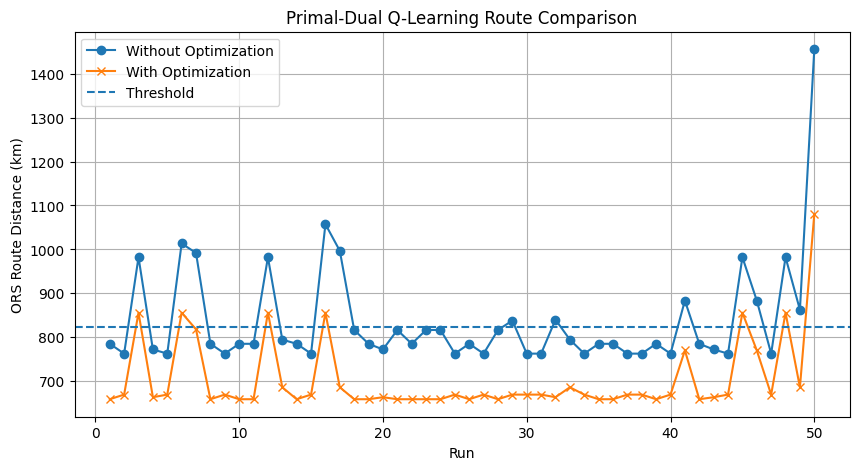

In [ ]:
import numpy as np
import openrouteservice
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import time

ORS_API_KEY = "API-Key"


# ---------------- TRAIN FUNCTION ----------------
def train_dual_q(env, agent, episodes=600, max_steps=10000):

    target_total_cost = 630.0
    mu_lr = 0.001

    episode_distances = []
    episode_rewards = []
    episode_steps = []
    episode_mus = []

    for episode in range(episodes):

        state = env.reset()
        done = False
        total_reward = 0
        total_cost = 0
        steps = 0

        while not done and steps < max_steps:

            actions = env.get_actions(state)
            if not actions:
                break

            action = agent.choose_action(state, actions)
            next_state, reward, cost, done = env.step(action)

            next_actions = env.get_actions(next_state)
            agent.learn(state, action, reward, cost, next_state, next_actions, done)

            total_reward += reward
            total_cost += cost
            state = next_state
            steps += 1

        cost_error = total_cost - target_total_cost
        agent.mu += mu_lr * cost_error
        agent.mu = float(np.clip(agent.mu, 0.01, 1.0))

        episode_distances.append(total_cost)
        episode_rewards.append(total_reward)
        episode_steps.append(steps)
        episode_mus.append(agent.mu)

    return episode_distances


# ---------------- TEST FUNCTION ----------------
def test_dual_q(env, agent, graph, start_node, max_steps=1000):

    agent.epsilon = 0.0

    state = env.reset()
    path = [state]

    coords = []
    lat, lon = graph.nodes[start_node]['pos']
    coords.append((lon, lat))

    done = False
    step_counter = 0

    while not done and step_counter < max_steps:

        actions = env.get_actions(state)
        if not actions:
            break

        action = agent.choose_action(state, actions)
        next_state, reward, cost, done = env.step(action)

        path.append(next_state)

        lat, lon = graph.nodes[next_state]['pos']
        coords.append((lon, lat))

        state = next_state
        step_counter += 1

    return path, coords, env.distance


# ---------------- ORS DISTANCE ----------------
def compute_ors_distance(coords):

    client = openrouteservice.Client(key=ORS_API_KEY)

    total_distance = 0
    start_idx = 0

    for end_idx in range(1, len(coords)):

        try:
            res = client.directions(
                coordinates=[coords[start_idx], coords[end_idx]],
                profile='driving-car',
                format='geojson',
                radiuses=[1000,1000]
            )

            dist = res['features'][0]['properties']['segments'][0]['distance']
            total_distance += dist

            start_idx = end_idx

        except:
            continue

    return total_distance / 1000


# ---------------- FILTERING FUNCTION ----------------
def filter_path_by_distance(path, graph, min_km=175, max_km=225):

    if not path or len(path) < 2:
        return path

    filtered_path = [path[0]]
    current = path[0]
    i = 1

    while i < len(path):

        found = False

        for j in range(i, len(path)):

            dist = geodesic(
                graph.nodes[current]['pos'],
                graph.nodes[path[j]]['pos']
            ).km

            if min_km <= dist <= max_km:

                filtered_path.append(path[j])
                current = path[j]
                i = j + 1
                found = True
                break

        if not found:

            filtered_path.append(path[i])
            current = path[i]
            i += 1

    return filtered_path


# ---------------- MAIN EXPERIMENT ----------------

runs = 50

success_raw = 0
success_filtered = 0

results = []

start_lat, start_lon = 34.05, -118.25
end_lat, end_lon = 37.7749, -122.4194

start_node = find_nearest_node(start_lat,start_lon)
goal_node = find_nearest_node(end_lat,end_lon)

actual_distance = 610
threshold = 1.35 * actual_distance

print("Actual distance:",actual_distance)
print("Threshold:",threshold)


for run in range(runs):

    print("\nRUN",run+1)

    env = EVRouteEnv(G,start_node,goal_node,preferred_connector_type='J1772')
    agent = DualQAgent(G,alpha=0.1,gamma=0.9,epsilon=0.2,mu=0.05)

    # TRAIN
    train_dual_q(env,agent)

    # TEST
    path,coords,model_distance = test_dual_q(env,agent,G,start_node)

    # ORS RAW
    ors_raw = compute_ors_distance(coords)
    print("ORS Raw:",ors_raw)
    time.sleep(15)
    print("First Sleep Over")

    # FILTER PATH
    filtered_path = filter_path_by_distance(path,G)

    filtered_coords = [(G.nodes[n]['pos'][1],G.nodes[n]['pos'][0]) for n in filtered_path]

    # ORS FILTERED
    ors_filtered = compute_ors_distance(filtered_coords)

    
    print("ORS Filtered:",ors_filtered)
    time.sleep(15)
    print("Second Sleep Over")

    raw_success = ors_raw <= threshold
    filtered_success = ors_filtered <= threshold

    if raw_success:
        success_raw += 1

    if filtered_success:
        success_filtered += 1

    results.append({
        "run":run+1,
        "raw":ors_raw,
        "filtered":ors_filtered
    })


# ---------------- FINAL RESULTS ----------------

raw_rate = (success_raw/runs)*100
filtered_rate = (success_filtered/runs)*100

print("\n==========================")
print("Runs:",runs)
print("Raw Success:",success_raw," Rate:",raw_rate,"%")
print("Filtered Success:",success_filtered," Rate:",filtered_rate,"%")
print("==========================")

# Plot comparison

raw_vals = [r["raw"] for r in results]
filtered_vals = [r["filtered"] for r in results]

plt.figure(figsize=(10,5))
plt.plot(range(1,runs+1),raw_vals,label="Without Optimization",marker='o')
plt.plot(range(1,runs+1),filtered_vals,label="With Optimization",marker='x')
plt.axhline(threshold,linestyle="--",label="Threshold")
plt.xlabel("Run")
plt.ylabel("ORS Route Distance (km)")
plt.title("Primal-Dual Q-Learning Route Comparison")
plt.legend()
plt.grid(True)
plt.show()